# Unsupervised Learning: Customer Segmentation
**Goal:** Segment 500 retail customers using K-Means clustering and visualise the groupings via PCA.

Features: `age` · `annual_spend` · `visits_per_month` · `basket_size` · `days_since_last_visit` · `num_categories_purchased`


## 1. Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# Load dataset
df = pd.read_csv('q2_customers.csv')
features = ['age', 'annual_spend', 'visits_per_month', 'basket_size',
            'days_since_last_visit', 'num_categories_purchased']

print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print()
display(df.head())
print()
df[features].describe().round(2)

Shape: (500, 6)
Missing values: 0



,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
count,500.00,500.00,500.00,500.00,500.00,500.00
mean,40.45,48856.95,8.41,2682.29,49.47,4.66
std,14.43,32856.80,5.32,2274.96,49.70,2.44
min,18.00,5038.00,1.00,212.00,0.00,1.00
25%,28.00,19213.25,4.00,727.75,12.00,3.00
50%,41.00,44257.00,8.00,2051.50,33.00,4.00
75%,50.00,75373.00,12.00,4223.75,61.25,6.00
max,69.00,119757.00,19.00,7981.00,179.00,9.00


In [2]:
# Scale all features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("Scaled data — mean ≈ 0, std ≈ 1 per feature:")
print(X_scaled_df.describe().round(3))

Scaled data — mean ≈ 0, std ≈ 1 per feature:
           age  annual_spend  visits_per_month  basket_size  \
count  500.000       500.000           500.000      500.000   
mean     0.000         0.000             0.000       -0.000   
std      1.001         1.001             1.001        1.001   
min     -1.558        -1.335            -1.394       -1.087   
25%     -0.864        -0.903            -0.830       -0.860   
50%      0.038        -0.140            -0.078       -0.278   
75%      0.662         0.808             0.674        0.678   
max      1.981         2.160             1.990        2.331   

       days_since_last_visit  num_categories_purchased  
count                500.000                   500.000  
mean                  -0.000                    -0.000  
std                    1.001                     1.001  
min                   -0.996                    -1.502  
25%                   -0.755                    -0.681  
50%                   -0.332                 

### Why Scaling is Essential Before K-Means

K-Means assigns each point to its nearest centroid using **Euclidean distance**. If features are on different numerical scales, the distance calculation is dominated by whichever feature has the largest absolute values — regardless of whether that feature is actually the most informative.

In this dataset the raw scale differences are extreme:

| Feature | Typical range | Units |
|---|---|---|
| `age` | 18–69 | years |
| `annual_spend` | ~14 000–90 000 | currency |
| `visits_per_month` | 1–20 | count |
| `basket_size` | ~500–6 000 | currency |
| `days_since_last_visit` | 0–180 | days |
| `num_categories_purchased` | 1–9 | count |

Without scaling, `annual_spend` and `basket_size` would contribute thousands of units to every distance, while `num_categories_purchased` contributes at most 8. The algorithm would effectively ignore the smaller-scale features entirely and cluster purely on spending magnitude.

`StandardScaler` transforms each feature to **mean = 0 and standard deviation = 1**, putting all six features on an equal footing so every dimension contributes proportionally to cluster formation. This is a non-negotiable prerequisite for distance-based algorithms like K-Means.


## 2. Choosing K — Elbow Method

In [3]:
# Compute WCSS for K = 1 … 10
wcss = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
    print(f"  K = {k:2d}  |  WCSS = {km.inertia_:8.2f}")

  K =  1  |  WCSS =  3000.00
  K =  2  |  WCSS =   968.99
  K =  3  |  WCSS =   561.25
  K =  4  |  WCSS =   444.93
  K =  5  |  WCSS =   402.37
  K =  6  |  WCSS =   370.39


  K =  7  |  WCSS =   346.95
  K =  8  |  WCSS =   319.90
  K =  9  |  WCSS =   303.28


  K = 10  |  WCSS =   289.11


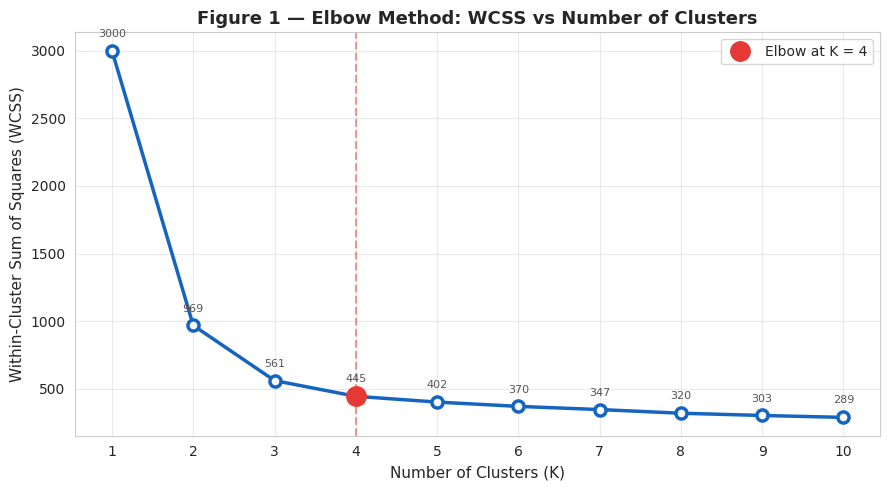

In [4]:
# Elbow plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(list(K_range), wcss, 'o-', color='#1565C0', linewidth=2.5,
        markersize=8, markerfacecolor='white', markeredgewidth=2.5)

# Highlight the elbow
elbow_k = 4
ax.plot(elbow_k, wcss[elbow_k - 1], 'o', color='#E53935',
        markersize=14, zorder=5, label=f'Elbow at K = {elbow_k}')
ax.axvline(elbow_k, color='#E53935', linestyle='--', alpha=0.5)

# Annotate each point
for k, w in zip(K_range, wcss):
    ax.annotate(f'{w:.0f}', xy=(k, w), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=8, color='#555')

ax.set_title('Figure 1 — Elbow Method: WCSS vs Number of Clusters', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Clusters (K)', fontsize=11)
ax.set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=11)
ax.set_xticks(list(K_range))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

### Optimal K Selection: K = 4

Inspecting the WCSS values and the elbow plot:

| K | WCSS | Drop from previous |
|---|---|---|
| 1 | 3000.00 | — |
| 2 | 969.00 | −2031.0 (67.7%) |
| 3 | 561.25 | −407.7 (42.1%) |
| **4** | **444.93** | **−116.3 (20.7%)** |
| 5 | 402.37 | −42.6 ( 9.6%) |
| 6 | 370.39 | −31.9 ( 7.9%) |

The marginal gain in inertia reduction drops sharply after K = 4:

- From K=2→3 the WCSS falls by ~42% — a large, meaningful reduction.
- From K=3→4 it falls by ~21% — still a substantial gain.
- From K=4→5 the drop is only ~10%, and the elbow curve begins to flatten noticeably.
- Beyond K=5 improvements are incremental and the curve becomes nearly linear.

**K = 4 is selected** as the point where additional clusters stop providing meaningfully tighter groupings — the canonical "elbow" of the curve. Four clusters also yields a business-interpretable segmentation without over-fragmenting the customer base.


## 3. K-Means Clustering

In [5]:
# Fit K-Means with K = 4
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Add cluster labels to the dataframe
df['cluster'] = kmeans.labels_

print(f"K-Means converged in {kmeans.n_iter_} iterations")
print(f"Final WCSS (inertia): {kmeans.inertia_:.2f}")
print()
print("Cluster sizes:")
print(df['cluster'].value_counts().sort_index().rename('count').to_frame())

K-Means converged in 4 iterations
Final WCSS (inertia): 444.93

Cluster sizes:
         count
cluster       
0          170
1           80
2          165
3           85


In [6]:
# Cluster centroids in original (unscaled) space for interpretability
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids_orig, columns=features)
centroids_df.index.name = 'Cluster'

print("Cluster Centroids (original feature scale):")
display(centroids_df.round(1))

Cluster Centroids (original feature scale):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
Cluster,,,,,,
0,24.7,14847.4,14.3,559.0,9.1,2.1
1,57.0,89814.1,2.5,5296.4,148.0,7.5
2,40.4,43340.7,8.2,2021.7,35.2,4.4
3,56.5,89036.2,2.6,5751.0,65.2,7.5


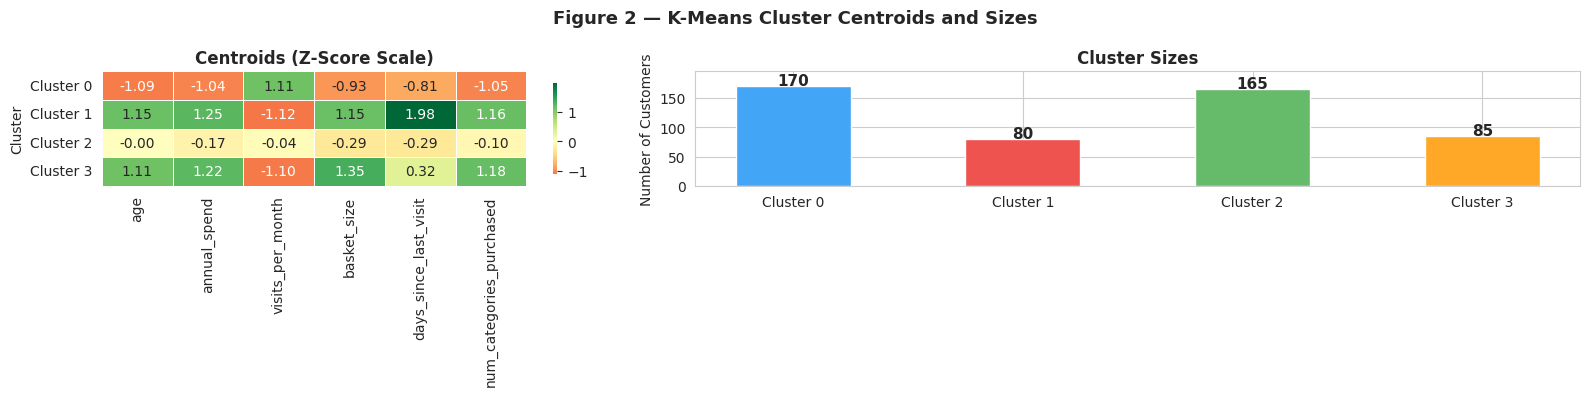

In [7]:
# Heatmap of normalised centroids (z-scores) for visual comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={'width_ratios': [1.2, 2]})

# Left: heatmap
cent_scaled = pd.DataFrame(kmeans.cluster_centers_, columns=features)
cent_scaled.index.name = 'Cluster'
sns.heatmap(cent_scaled, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Centroids (Z-Score Scale)', fontweight='bold')
axes[0].set_yticklabels([f'Cluster {i}' for i in range(K)], rotation=0)

# Right: bar chart of cluster sizes
counts = df['cluster'].value_counts().sort_index()
cluster_colors = ['#42A5F5', '#EF5350', '#66BB6A', '#FFA726']
bars = axes[1].bar([f'Cluster {i}' for i in counts.index], counts.values,
                    color=cluster_colors, edgecolor='white', width=0.5)
for bar, v in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 2, str(v),
                 ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Cluster Sizes', fontweight='bold')
axes[1].set_ylabel('Number of Customers')
axes[1].set_ylim(0, max(counts.values) * 1.15)

plt.suptitle('Figure 2 — K-Means Cluster Centroids and Sizes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Business Interpretation of Clusters

Based on the centroid values in original feature space:

| | Cluster 0 | Cluster 1 | Cluster 2 | Cluster 3 |
|---|---|---|---|---|
| **Age** | 24.7 | 57.0 | 40.4 | 56.5 |
| **Annual Spend** | £14,847 | £89,814 | £43,341 | £89,036 |
| **Visits/Month** | 14.3 | 2.5 | 8.2 | 2.6 |
| **Basket Size** | £559 | £5,296 | £2,022 | £5,751 |
| **Days Since Last Visit** | 9.1 | 148.0 | 35.2 | 65.2 |
| **Categories Purchased** | 2.1 | 7.5 | 4.4 | 7.5 |
| **Size** | 170 | 80 | 165 | 85 |

---

🔵 **Cluster 0 — "Young Frequent Browsers"** (n = 170, 34%)  
Young customers (avg age 24.7) who visit very frequently (~14×/month) but spend little per trip (£559 basket, £14.8k annual). They browse across only 2 categories and last visited just 9 days ago. **High engagement, low value** — candidates for upselling and category expansion campaigns.

🔴 **Cluster 1 — "Lapsed High-Value Seniors"** (n = 80, 16%)  
Older customers (avg age 57) with very high spend (£89.8k annual, £5.3k baskets) and broad category purchases (7.5 categories), but who have **not visited in ~148 days**. They were clearly high-value but are now churning. **Top priority for win-back campaigns.**

🟢 **Cluster 2 — "Engaged Mid-Tier"** (n = 165, 33%)  
Middle-aged customers (avg 40.4) with moderate-to-good engagement: visit 8×/month, spend £43.3k annually, and last visited 35 days ago. They are the **stable backbone** of the customer base — well-suited for loyalty programme investments and moderate upsell offers.

🟠 **Cluster 3 — "Occasional Premium Spenders"** (n = 85, 17%)  
Older customers (avg 56.5) who spend as much as Cluster 1 (£89k annual, £5.75k baskets) across 7.5 categories but visit infrequently (2.6×/month) — though with a healthier recency of 65 days. **High-value but low-frequency** — could be moved toward Cluster 1's risk profile without targeted engagement. Focus on visit-frequency incentives.


## 4. Dimensionality Reduction with PCA

In [8]:
# Apply PCA — 2 principal components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("=== Explained Variance Ratio ===")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f}  ({var*100:.2f}%)")
print(f"  Total: {pca.explained_variance_ratio_.sum():.4f}  ({pca.explained_variance_ratio_.sum()*100:.2f}%)")

=== Explained Variance Ratio ===
  PC1: 0.8356  (83.56%)
  PC2: 0.0557  (5.57%)
  Total: 0.8913  (89.13%)


In [9]:
# Feature loadings
loadings_df = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=['PC1', 'PC2']
).round(4)

print("=== Feature Loadings (Components) ===")
display(loadings_df)

=== Feature Loadings (Components) ===


,PC1,PC2
age,0.4116,-0.2594
annual_spend,0.4215,-0.0333
visits_per_month,-0.4104,0.2083
basket_size,0.4120,-0.1954
days_since_last_visit,0.3786,0.9112
num_categories_purchased,0.4140,-0.1405


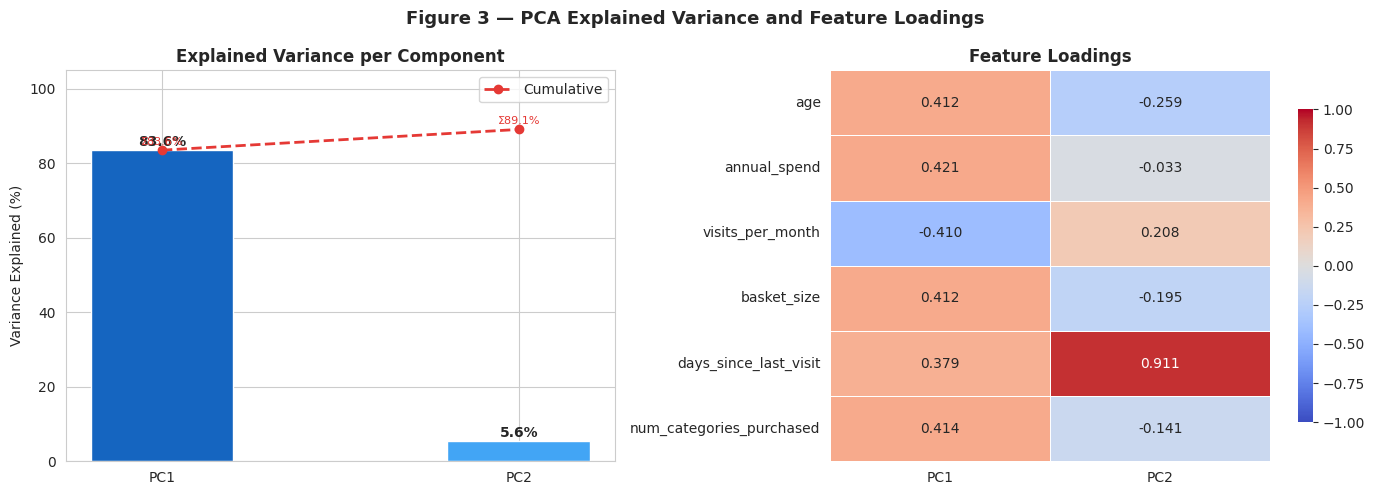

In [10]:
# Visualise explained variance and loadings
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scree plot
var_ratio = pca.explained_variance_ratio_
cumulative = np.cumsum(var_ratio)
axes[0].bar(['PC1', 'PC2'], var_ratio * 100, color=['#1565C0', '#42A5F5'], edgecolor='white', width=0.4)
axes[0].plot(['PC1', 'PC2'], cumulative * 100, 'o--', color='#E53935', linewidth=2, label='Cumulative')
for i, (v, c) in enumerate(zip(var_ratio, cumulative)):
    axes[0].text(i, v * 100 + 1, f'{v*100:.1f}%', ha='center', fontweight='bold')
    axes[0].text(i, c * 100 + 1.5, f'Σ{c*100:.1f}%', ha='center', color='#E53935', fontsize=8)
axes[0].set_title('Explained Variance per Component', fontweight='bold')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_ylim(0, 105)
axes[0].legend()

# Right: loading heatmap
sns.heatmap(loadings_df, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=axes[1], vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
axes[1].set_title('Feature Loadings', fontweight='bold')

plt.suptitle('Figure 3 — PCA Explained Variance and Feature Loadings', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpreting PC1 and PC2

**PC1 — "Overall Customer Value & Engagement Axis" (83.56% of variance)**

PC1 captures the vast majority of information in the dataset. All six features load heavily on this component:

| Feature | PC1 Loading | Direction |
|---|---|---|
| `annual_spend` | +0.422 | High spend → higher PC1 |
| `num_categories_purchased` | +0.414 | More categories → higher PC1 |
| `basket_size` | +0.412 | Larger baskets → higher PC1 |
| `age` | +0.412 | Older → higher PC1 |
| `days_since_last_visit` | +0.379 | Less recent → higher PC1 |
| `visits_per_month` | **−0.410** | More visits → **lower** PC1 |

PC1 is an axis of **customer maturity and value**: high PC1 scores represent older customers who spend a lot per trip across many categories but visit infrequently. Low PC1 scores represent younger, frequent-but-low-spend browsers. The negative loading on `visits_per_month` creates an intuitive contrast: high-frequency shoppers (young, low-basket) sit at one end; high-value, infrequent shoppers at the other.

---

**PC2 — "Recency / Dormancy Axis" (5.57% of variance)**

PC2 is dominated almost entirely by a single feature:

| Feature | PC2 Loading |
|---|---|
| `days_since_last_visit` | **+0.911** ← dominant |
| All others | < ±0.26 |

PC2 captures **how recently a customer visited**, largely independent of their spending or engagement profile. Customers displaced upward on PC2 have not shopped recently (lapsed/churning), while those near the bottom visited very recently. This component separates the "lapsed high-spenders" (Cluster 1) from the "occasional premium spenders" (Cluster 3), even though both have similar spending levels.

**Together**, PC1+PC2 preserve 89.1% of the total variance in just two dimensions — sufficient for meaningful cluster visualisation.


## 5. Cluster Visualisation

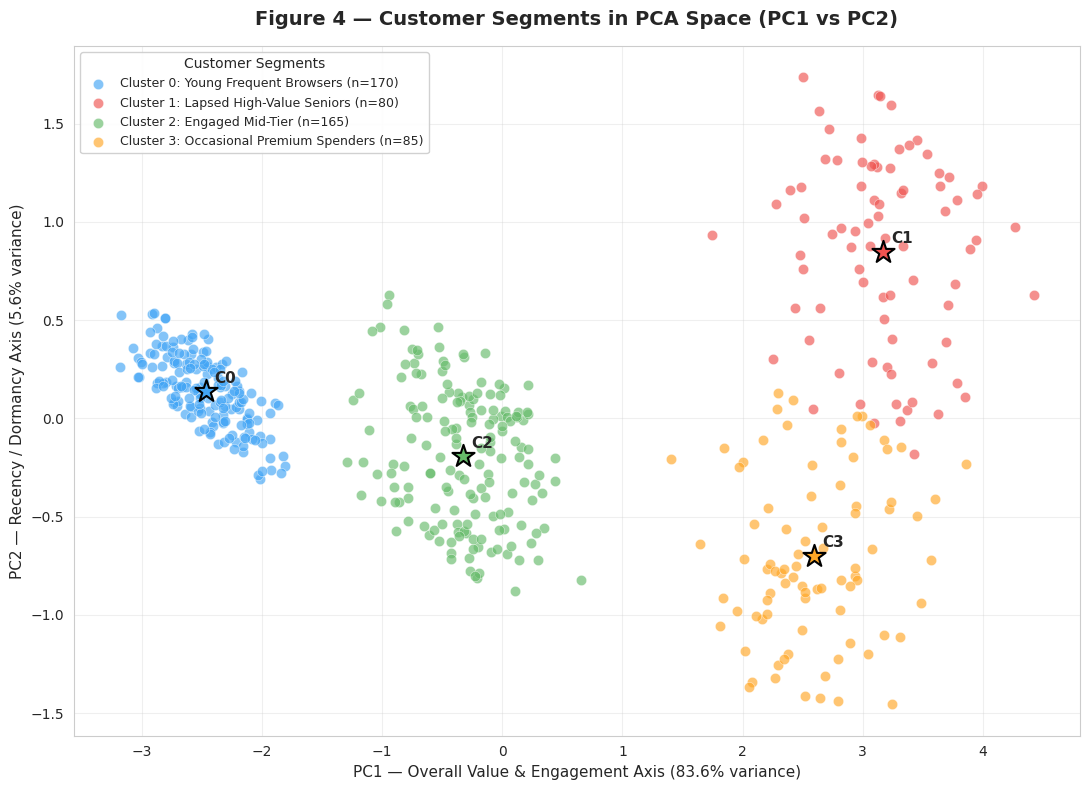


Figure notes:
  Stars (★) mark cluster centroids in PCA space.
  PC1 + PC2 explain 89.1% of total variance.


In [11]:
# Scatter plot: PC1 vs PC2, coloured by cluster
cluster_colors = ['#42A5F5', '#EF5350', '#66BB6A', '#FFA726']
cluster_labels = {
    0: 'Cluster 0: Young Frequent Browsers (n=170)',
    1: 'Cluster 1: Lapsed High-Value Seniors (n=80)',
    2: 'Cluster 2: Engaged Mid-Tier (n=165)',
    3: 'Cluster 3: Occasional Premium Spenders (n=85)'
}

fig, ax = plt.subplots(figsize=(11, 8))

for cluster_id in range(K):
    mask = df['cluster'] == cluster_id
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=cluster_colors[cluster_id],
        label=cluster_labels[cluster_id],
        alpha=0.65, s=55, edgecolors='white', linewidths=0.4
    )

# Plot centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
for i, (cx, cy) in enumerate(centroids_pca):
    ax.scatter(cx, cy, c=cluster_colors[i], s=280, marker='*',
               edgecolors='black', linewidths=1.5, zorder=10)
    ax.annotate(f'C{i}', xy=(cx, cy), xytext=(6, 6),
                textcoords='offset points', fontweight='bold', fontsize=11)

ax.set_title('Figure 4 — Customer Segments in PCA Space (PC1 vs PC2)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel(f'PC1 — Overall Value & Engagement Axis ({pca.explained_variance_ratio_[0]*100:.1f}% variance)',
              fontsize=11)
ax.set_ylabel(f'PC2 — Recency / Dormancy Axis ({pca.explained_variance_ratio_[1]*100:.1f}% variance)',
              fontsize=11)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9,
          title='Customer Segments', title_fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nFigure notes:")
print(f"  Stars (★) mark cluster centroids in PCA space.")
print(f"  PC1 + PC2 explain {pca.explained_variance_ratio_.sum()*100:.1f}% of total variance.")

### Visualisation Interpretation

The PCA scatter plot confirms the K-Means segmentation is well-structured:

- **Cluster 0 (blue)** and **Cluster 2 (green)** separate clearly along PC1 (the value axis): Cluster 0 clusters to the left (low value, high frequency), while Cluster 2 occupies the middle range.
- **Clusters 1 and 3 (red/orange)** both sit at the high-value right end of PC1, but are separated vertically by PC2 — Cluster 1 (lapsed) sits higher (more days since last visit) while Cluster 3 (occasional) sits lower (more recent).
- Minimal overlap between groups confirms K = 4 produces well-separated, meaningful segments rather than arbitrary partitions.
- The fact that over 83% of variance is captured in PC1 alone explains why the four clusters are most visibly spread along the horizontal axis.
